# Task 2: Neural CTR Prediction

## Objective

The goal of this task is to predict whether an ad impression results in a click.

The dataset contains 13 numerical features, 26 categorical features, and a binary target label.

I will first build a vanilla neural network baseline, compare a few small architectures using a validation set, and then evaluate the selected model on the untouched test set.

Further I will also investigate training behaviour, overfitting, and the effect of handling numerical and categorical features.

## 1. Dataset Overview

Each row represents an ad impression.

The target variable label indicates whether the user clicked the ad:

0 : no click

1 : click

The dataset contains separate training and testing files. The test set will be kept untouched during model and architecture selection.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Training shape:", train.shape)
print("Testing shape:", test.shape)

Training shape: (40000, 40)
Testing shape: (10000, 40)


In [6]:
train.head()

,label,integer_feature_1,integer_feature_2,integer_feature_3,integer_feature_4,integer_feature_5,integer_feature_6,integer_feature_7,integer_feature_8,integer_feature_9,...,categorical_feature_17,categorical_feature_18,categorical_feature_19,categorical_feature_20,categorical_feature_21,categorical_feature_22,categorical_feature_23,categorical_feature_24,categorical_feature_25,categorical_feature_26
0,0,49.0,520.0,0.0,353.0,5.0,0.0,0.0,0,2,...,1f7fc70b,628f1b8d,9512c20b,c5362157,a9ad4e8e,2b6a4b2f,bc71cd9d,9f4102b0,ff654802,2f33557c
1,0,NaN,408.0,NaN,NaN,NaN,0.0,0.0,-1,1,...,NaN,a1eb1511,0a1d513f,7fdb0729,747f6ecc,62682372,NaN,401a16fe,30436bfc,b757e957
2,0,28.0,37.0,2.0,5.0,4.0,5.0,1.0,974,14,...,753da5f3,d9f758ff,9512c20b,682d90ba,09afda28,307a0f03,f942364c,16e6b497,57e36578,a7ab145d
3,0,1.0,603.0,1.0,NaN,1.0,0.0,0.0,13,1,...,NaN,b8170bba,108a0699,47849e55,73b3f46d,d994ba60,NaN,328e967b,ff654802,2ba8d787
4,0,NaN,525.0,3.0,8.0,126.0,1.0,0.0,10,11,...,753da5f3,b8170bba,55191c09,0e29b5da,0683bc6f,47b99d80,d2b125b2,00a688ec,30436bfc,b757e957


In [7]:
numeric_features = [
    col for col in train.columns
    if col.startswith("integer_feature_")
]

categorical_features = [
    col for col in train.columns
    if col.startswith("categorical_feature_")
]

target = "label"

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 13
Categorical features: 26


Finding Missing Values

In [8]:
missing = train.isna().sum()



In [9]:
missing

,0
label,0
integer_feature_1,7396
integer_feature_2,3476
integer_feature_3,9817
integer_feature_4,15995
integer_feature_5,15413
integer_feature_6,3527
integer_feature_7,1213
integer_feature_8,0
integer_feature_9,0


In [10]:
label_counts = train["label"].value_counts()

print(label_counts)
print("\nClick rate:", train["label"].mean())

label
0    38720
1     1280
Name: count, dtype: int64

Click rate: 0.032


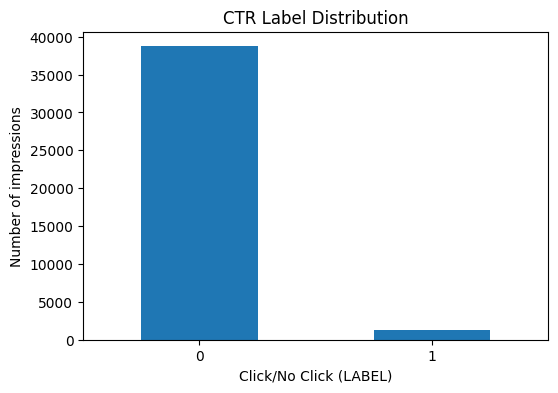

In [11]:
label_counts.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.xlabel("Click/No Click (LABEL)")
plt.ylabel("Number of impressions")
plt.title("CTR Label Distribution")
plt.xticks(rotation=0)
plt.show()

In [12]:
import tensorflow as tf

In [13]:
X = train.drop(columns=["label"])
y = train["label"]

print(X.shape)
print(y.shape)

(40000, 39)
(40000,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (32000, 39)
Validation: (8000, 39)


NUMERICAL FEATURES : Using median to handle missing val

In [15]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_num = imputer.fit_transform(
    X_train[numeric_features]
)

X_val_num = imputer.transform(
    X_val[numeric_features]
)

In [16]:
print(X_train_num.shape)
print(X_val_num.shape)

(32000, 13)
(8000, 13)


Didnt fit transform val column as we're calculating medians only from training data.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train_num)
X_val_num = scaler.transform(X_val_num)

I median-imputed the numerical features and standardized them. I fitted both preprocessing steps only on the training data to avoid data leakage.

CATEGORICAL FEATURES:

In [18]:
categorical_maps = {}

# for missing values - write MISSING

for col in categorical_features:
    values = X_train[col].fillna("MISSING").astype(str)

    unique_values = values.unique()

    # Im making integer IDs for each unique values

    mapping = {
        value: i + 1
        for i, value in enumerate(unique_values)
    }

    # storing the mapping

    categorical_maps[col] = mapping

In [27]:
X_train_cat = []

for col in categorical_features:

    values = X_train[col].fillna("MISSING").astype(str)

    mapping = categorical_maps[col]

    values = values.map(mapping).fillna(0)

    X_train_cat.append(values.values)

X_train_cat = np.array(X_train_cat).T #Transposing to get same format as i/p

In [25]:
X_val_cat = []

for col in categorical_features:

    values = X_val[col].fillna("MISSING").astype(str)

    mapping = categorical_maps[col]

    values = values.map(mapping).fillna(0)

    X_val_cat.append(values.values)

X_val_cat = np.array(X_val_cat).T

In [28]:
print(X_train_cat.shape)
print(X_val_cat.shape)

(32000, 26)
(8000, 26)


In [29]:
X_train_cat = X_train_cat.astype("int32")
X_val_cat = X_val_cat.astype("int32")

In [30]:
embedding_sizes = []

for col in categorical_features:
    embedding_sizes.append(len(categorical_maps[col]) + 1) #+1 is for ID 0

print(embedding_sizes)

[10858, 3349, 4586, 1614, 3643, 4, 2912, 711, 23, 9625, 4772, 6821, 10, 821, 1833, 43, 5, 310, 15, 11112, 7581, 10423, 4362, 3258, 36, 25]


In [33]:
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense
from tensorflow.keras.models import Model

In [35]:
inputs = []
embeddings = []

for i in range(26):

    inp = Input(shape=(1,))

    emb = Embedding(
        input_dim=embedding_sizes[i],
        output_dim=16
    )(inp)

    emb = Flatten()(emb)

    inputs.append(inp)
    embeddings.append(emb)

numeric_input = Input(shape=(13,))

combined = Concatenate()(embeddings + [numeric_input])

x = Dense(128, activation="relu")(combined)
x = Dense(64, activation="relu")(x)

output = Dense(1, activation="sigmoid")(x)

model = Model(
    inputs=inputs + [numeric_input],
    outputs=output
)

In [36]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_27      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_28      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_29      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_30      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_31      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_32      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_33      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_34      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_35      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_36      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_37      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_38      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_39      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_40      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_41      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_42      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_43      │ (None, 1)         │          0 │ -               

 Total params: 1,483,393 (5.66 MB)

 Trainable params: 1,483,393 (5.66 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
train_inputs = []

for i in range(26):
    train_inputs.append(X_train_cat[:, i])

train_inputs.append(X_train_num)

In [40]:
val_inputs = []

for i in range(26):
    val_inputs.append(X_val_cat[:, i])

val_inputs.append(X_val_num)

In [41]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["AUC"]
)

In [42]:
history = model.fit(
    train_inputs,
    y_train,
    validation_data=(val_inputs, y_val),
    epochs=8,
    batch_size=256
)

Epoch 1/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - AUC: 0.5647 - loss: 0.1762 - val_AUC: 0.7165 - val_loss: 0.1328
Epoch 2/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - AUC: 0.8155 - loss: 0.1208 - val_AUC: 0.6828 - val_loss: 0.1387
Epoch 3/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - AUC: 0.9450 - loss: 0.0800 - val_AUC: 0.6159 - val_loss: 0.1924
Epoch 4/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - AUC: 0.9794 - loss: 0.0494 - val_AUC: 0.5973 - val_loss: 0.2278
Epoch 5/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - AUC: 0.9880 - loss: 0.0371 - val_AUC: 0.5874 - val_loss: 0.2473
Epoch 6/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - AUC: 0.9910 - loss: 0.0304 - val_AUC: 0.5819 - val_loss: 0.2778
Epoch 7/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - AUC: 0.9926 - loss: 0.0253 - val_AUC: 0.5733 - val_loss: 0.3069
Epoch 8/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - AUC: 0.9949 - loss: 0.0225 - val_AUC: 0.5688 - val_loss: 0.3245


In [43]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    log_loss,
    f1_score
)

val_predictions = model.predict(val_inputs).ravel()

print("ROC-AUC:", roc_auc_score(y_val, val_predictions))
print("PR-AUC:", average_precision_score(y_val, val_predictions))
print("Log Loss:", log_loss(y_val, val_predictions))

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
ROC-AUC: 0.5991725448734504
PR-AUC: 0.05197381209664763
Log Loss: 0.3218845175206137


In [44]:
val_classes = (val_predictions >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_val, val_classes))
print("F1:", f1_score(y_val, val_classes))

Accuracy: 0.938
F1: 0.06415094339622641


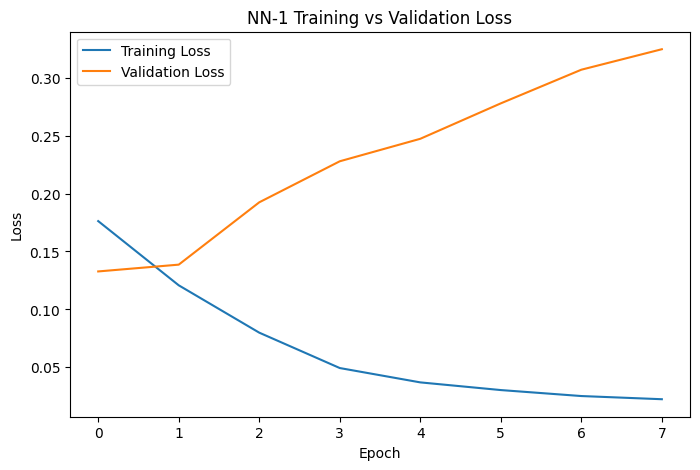

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("NN-1 Training vs Validation Loss")
plt.legend()

plt.show()

For AUC:

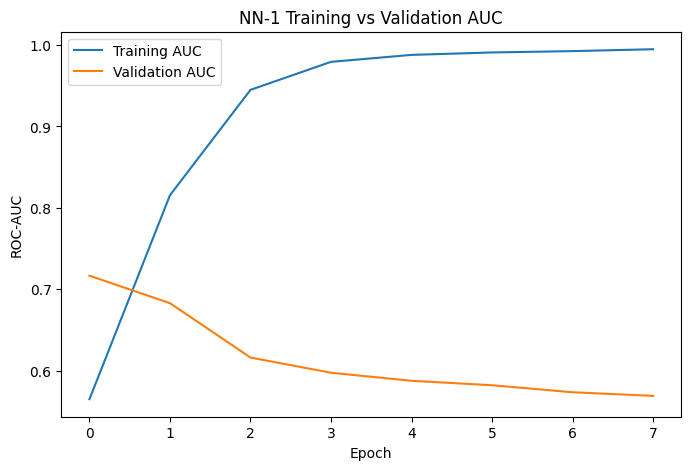

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["AUC"], label="Training AUC")
plt.plot(history.history["val_AUC"], label="Validation AUC")

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("NN-1 Training vs Validation AUC")
plt.legend()

plt.show()

In [49]:
from tensorflow.keras.layers import Dropout

inputs = []
embeddings = []

for i in range(26):
    inp = Input(shape=(1,))

    emb = Embedding(
        input_dim=embedding_sizes[i],
        output_dim=16
    )(inp)

    emb = Flatten()(emb)

    inputs.append(inp)
    embeddings.append(emb)

numeric_input = Input(shape=(13,))

combined = Concatenate()(embeddings + [numeric_input])

x = Dense(128, activation="relu")(combined)
x = Dropout(0.3)(x)

x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)

output = Dense(1, activation="sigmoid")(x)

model = Model(
    inputs=inputs + [numeric_input],
    outputs=output
)

In [50]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="roc_auc")
    ]
)

Implementing Early Stopping

In [51]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_roc_auc",
    patience=2,
    mode="max",
    restore_best_weights=True
)

In [52]:
history = model.fit(
    train_inputs,
    y_train,
    validation_data=(val_inputs, y_val),
    epochs=10,
    batch_size=256,
    callbacks=[early_stop]
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - loss: 0.1977 - roc_auc: 0.5538 - val_loss: 0.1329 - val_roc_auc: 0.7175
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.1300 - roc_auc: 0.7385 - val_loss: 0.1347 - val_roc_auc: 0.7036
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0952 - roc_auc: 0.9078 - val_loss: 0.1674 - val_roc_auc: 0.6341


In [53]:
val_predictions = model.predict(val_inputs).ravel()

val_classes = (val_predictions >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_val, val_predictions))
print("PR-AUC:", average_precision_score(y_val, val_predictions))
print("Log Loss:", log_loss(y_val, val_predictions))
print("Accuracy:", accuracy_score(y_val, val_classes))
print("F1:", f1_score(y_val, val_classes))

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
ROC-AUC: 0.7170238652505165
PR-AUC: 0.07902336553508285
Log Loss: 0.13294061606320565
Accuracy: 0.968
F1: 0.0


F1 score is 0 likely due to strong class imbalance in set

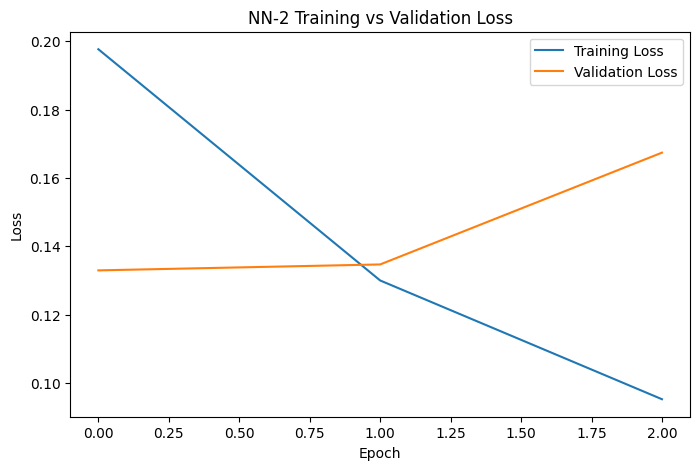

In [55]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("NN-2 Training vs Validation Loss")
plt.legend()

plt.show()

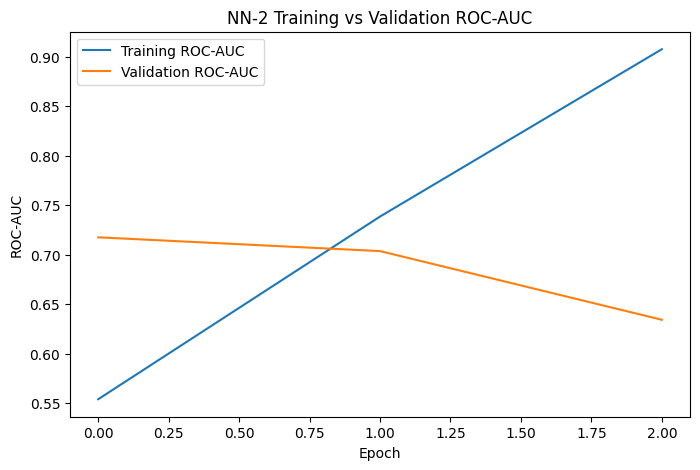

In [56]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["roc_auc"], label="Training ROC-AUC")
plt.plot(history.history["val_roc_auc"], label="Validation ROC-AUC")

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("NN-2 Training vs Validation ROC-AUC")
plt.legend()

plt.show()

In [57]:
results = pd.DataFrame({
    "Model": ["NN-1", "NN-2"],
    "ROC-AUC": [0.599, 0.717],
    "PR-AUC": [0.052, 0.079],
    "Log Loss": [0.322, 0.132],
    "Accuracy": [0.938, 0.968],
    "F1": [0.064, 0.000]
})

results

,Model,ROC-AUC,PR-AUC,Log Loss,Accuracy,F1
0,NN-1,0.599,0.052,0.322,0.938,0.064
1,NN-2,0.717,0.079,0.132,0.968,0.000


Now Using Test Set

Numerical:

In [58]:
X_test_num = imputer.transform(
    test[numeric_features]
)

X_test_num = scaler.transform(
    X_test_num
)

Categorical

In [59]:
X_test_cat = []

for col in categorical_features:

    values = test[col].fillna("MISSING").astype(str)

    mapping = categorical_maps[col]

    values = values.map(mapping).fillna(0)

    X_test_cat.append(values.values)

X_test_cat = np.array(X_test_cat).T

print(X_test_cat.shape)

(10000, 26)


In [62]:
test_inputs = []

for i in range(26):
    test_inputs.append(X_test_cat[:, i])

test_inputs.append(X_test_num)

test_predictions = model.predict(test_inputs).ravel()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step


In [63]:
print(test_predictions[:10])

[0.0282845  0.04383425 0.01478211 0.00026504 0.02577858 0.01210202
 0.03565437 0.04065322 0.03760519 0.03118194]


Therse are badically the predicted click probabilities for the 10,000 test impressions